In [53]:
# Import libraries
import os
from tensorflow import keras
import pandas as pd
import numpy as np
import tensorflow as tf
import tarfile
import urllib.request
import shutil
import matplotlib.pyplot as plt

# Dataset Preparation

In [54]:
# Paths and URLs
url = "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz"
base_dir = os.path.expanduser("~/cora_dataset")
tgz_path = os.path.join(base_dir, "cora.tgz")
cora_dir = os.path.join(base_dir, "cora")
cites_file = os.path.join(cora_dir, "cora.cites")
content_file = os.path.join(cora_dir, "cora.content")

# Download dataset
os.makedirs(base_dir, exist_ok=True)
if not os.path.exists(tgz_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, tgz_path)

# Extract dataset
if not os.path.exists(cora_dir):
    print("Extracting dataset...")
    with tarfile.open(tgz_path, "r:gz") as tar:
        tar.extractall(path=base_dir)

# Load cora.cites
if os.path.exists(cites_file):
    citations = pd.read_csv(cites_file, sep="\t", header=None, names=["target", "source"])
    print("Loaded cora.cites:", citations.shape)
    print(citations.sample(5))
else:
    print("Missing cora.cites")

# Load cora.content
if os.path.exists(content_file):
    # Add header=None and names to explicitly specify column names
    column_names = ["paper_id"] + [f"word_{idx}" for idx in range(1433)] + ["subject"]
    papers = pd.read_csv(content_file, sep="\t", header=None, names=column_names)
    print("Loaded cora.content:", papers.shape)
    sample = papers.sample(10)
    print(sample.iloc[:, list(range(10)) + [-1]])
else:
    print("Missing cora.content")

Loaded cora.cites: (5429, 2)
      target   source
2809   33895  1153577
187      114   193742
3834   89547  1112319
2528   27530    27531
5235  644448  1131258
Loaded cora.content: (2708, 1435)
      paper_id  word_0  word_1  word_2  word_3  word_4  word_5  word_6  \
2083   1135750       0       0       0       0       0       0       0   
2468     18785       0       0       0       0       1       0       0   
2575    633721       0       0       0       0       0       0       0   
976     158172       0       0       0       0       0       0       0   
1485    815096       0       0       0       0       0       0       0   
1653   1131828       0       0       0       0       0       0       0   
2615     14545       0       0       0       0       0       0       0   
547     328370       0       0       0       0       0       0       0   
1610    140569       0       0       0       0       0       0       0   
653    1120170       0       0       0       0       0       0   

In [55]:
# Get list of unique paper subjects / classes. These are the labels for Node (Paper) Classification.
class_values = sorted(papers["subject"].unique())

# Generate corresponding list of unique class indices
class_idx = {name: idx for idx, name in enumerate(class_values)}

# Generate list of unique class indices
paper_idx = {name: idx for idx, name in enumerate(sorted(papers["paper_id"].unique()))}

# Map original paper index to the new paper index
papers["paper_id"] = papers["paper_id"].apply(lambda name: paper_idx[name])

# Map original paper subject (string) to the new paper subject (integer)
papers["subject"] = papers["subject"].apply(lambda value: class_idx[value])

# Map original source/target paper index to the new source/target paper index
citations["source"] = citations["source"].apply(lambda name: paper_idx[name])
citations["target"] = citations["target"].apply(lambda name: paper_idx[name])

# Print some citation samples with new index mapping
print("Citations shape:", citations.shape)
citations.sample(n=10)

# Print some citation samples with new index mapping
print("Papers shape:", papers.shape)
papers.sample(n=10)

Citations shape: (5429, 2)
Papers shape: (2708, 1435)


,paper_id,word_0,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,...,word_1424,word_1425,word_1426,word_1427,word_1428,word_1429,word_1430,word_1431,word_1432,subject
1434,1382,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
932,2132,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
465,111,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
598,2486,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
2069,1824,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
462,855,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
698,483,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,2
738,424,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
2426,152,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
769,2368,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


# DNN

In [56]:
# Set train, validation, and test ratios
train_data, val_data, test_data = [], [], []
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Set random seed to get the same training set and test set in different running times.
np.random.seed(0)

# Select training_ratio from each group of paper subject to form the training set
for _, group_data in papers.groupby("subject"):
    # Get a random list of probabilities from a subject group
    random_probs = np.random.rand(len(group_data.index))

    # Split into train, val, and test
    random_selection_train = random_probs <= train_ratio
    random_selection_val = (train_ratio < random_probs) & (random_probs <= train_ratio + val_ratio)
    random_selection_test = 1 - test_ratio < random_probs

    # Add group DataFrames containing paper indices to training, validation and test sets
    train_data.append(group_data[random_selection_train])
    val_data.append(group_data[random_selection_val])
    test_data.append(group_data[random_selection_test])

# Concat list of DataFrames to a big DataFrame for training and test dataset
train_data = pd.concat(train_data)
val_data = pd.concat(val_data)
test_data = pd.concat(test_data)

print("Training set:", train_data.shape)
print("Validation set:", val_data.shape)
print("Test set:", test_data.shape)


Training set: (1863, 1435)
Validation set: (405, 1435)
Test set: (440, 1435)


In [57]:
# List of features (word attributes) of a paper (node)
feature_names = set(papers.columns) - {"paper_id", "subject"}

# Create tensors of data samples
x_train = train_data[list(feature_names)].to_numpy()
x_val = val_data[list(feature_names)].to_numpy()
x_test = test_data[list(feature_names)].to_numpy()

# Create tensors of data labels
y_train = train_data["subject"]
y_val = val_data["subject"]
y_test = test_data["subject"]

# Number of features (word attributes) of a paper (node)
num_features = len(feature_names)

# Number of labels (subjects) of a paper
num_classes = len(class_idx)


In [58]:
# Feed Forward Network setup: number of FC layers and number of nodes in each FC layer
hidden_units = [32, 32]

# Feed Forward Network setup: dropout rate at DropOut layer
dropout_rate = 0.5

# import layers from keras
from tensorflow.keras import layers

# Create a Feed Forward Network (FFN) as a Sequential model
def create_ffn(hidden_units_ffn, dropout_rate_ffn):
    fnn_layers = []

    for units in hidden_units_ffn:
        fnn_layers.append(layers.Dense(units, activation=tf.nn.gelu))
        fnn_layers.append(layers.Dropout(dropout_rate_ffn))
        fnn_layers.append(layers.BatchNormalization())

    # A Sequential model is appropriate for a plain stack of layers where each layer has exactly one input tensor and one output tensor
    return keras.Sequential(fnn_layers)

# Create a Deep Neural Network (DNN) for node classification
def create_dnn_model(hidden_units_ffn, dropout_rate_ffn, model_name):
    # Input of DNN is paper feature. Originally each paper has 1433 (num_features) word attributes as features.
    inputs = layers.Input(shape=(num_features,))

    # Embed the original features dimension to hidden_units space by using the Feed Forward Network (FFN).
    x = create_ffn(hidden_units_ffn, dropout_rate_ffn)(inputs)

    # Then perform feature extraction by using some skip connection blocks
    for block_idx in range(4):
        # Create an FFN block
        x1 = create_ffn(hidden_units_ffn, dropout_rate_ffn)(x)
        # Add skip connection
        x = x + x1

    # Add output layer
    outputs = layers.Dense(num_classes, activation = tf.nn.softmax)(x)

    # Create the model.
    return keras.Model(inputs=inputs, outputs=outputs, name=model_name)

dnn_model = create_dnn_model(hidden_units, dropout_rate, "DNN")
dnn_model.summary()

# Compile the DNN model
dnn_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.01),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy(name="acc")],
)

# Train and validate the DNN model
history_dnn = dnn_model.fit(
    x = x_train,
    y = y_train,
    epochs = 100,
    batch_size = 1024,
    validation_data = (x_val, y_val)
)

dnn_model_eval = dnn_model.evaluate(x_test, y_test)
print("List of metrics" + str(dnn_model.metrics_names)) # List of possible metrics of the model evaluation, this is the metrics specified in the model.compile().
print("Test loss: " + str(dnn_model_eval[0])) # Test loss
print("Test accuracy: " + str(dnn_model_eval[1])) # Test accuracy

Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 1433)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 32)        │     47,200 │ input_layer_6[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 32)        │      2,368 │ sequential_5[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 32)        │          0 │ sequential_5[0][… │
│                     │                   │            │ sequential_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 32)        │      2,368 │ add_4[0][0]       │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 32)        │          0 │ add_4[0][0],      │
│                     │                   │            │ sequential_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 32)        │      2,368 │ add_5[0][0]       │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 32)        │          0 │ add_5[0][0],      │
│                     │                   │            │ sequential_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 32)        │      2,368 │ add_6[0][0]       │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 32)        │          0 │ add_6[0][0],      │
│                     │                   │            │ sequential_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 7)         │        231 │ add_7[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 56,903 (222.28 KB)

 Trainable params: 56,263 (219.78 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - acc: 0.1727 - loss: 3.8756 - val_acc: 0.3160 - val_loss: 1.8957
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - acc: 0.2219 - loss: 3.0261 - val_acc: 0.3160 - val_loss: 1.8756
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - acc: 0.2597 - loss: 2.5401 - val_acc: 0.3160 - val_loss: 1.8468
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - acc: 0.3112 - loss: 2.1928 - val_acc: 0.3210 - val_loss: 1.8099
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - acc: 0.3281 - loss: 2.1239 - val_acc: 0.3333 - val_loss: 1.7771
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - acc: 0.3600 - loss: 1.9011 - val_acc: 0.3630 - val_loss: 1.7478
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - acc: 0.3920 - loss: 1.7636 - val_acc: 0.3753 - val_loss: 1.7177
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - acc: 0.4105 - loss: 1.6764 - val_acc: 0.3852 - val_loss: 1.6883
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - acc: 0.4327 - 

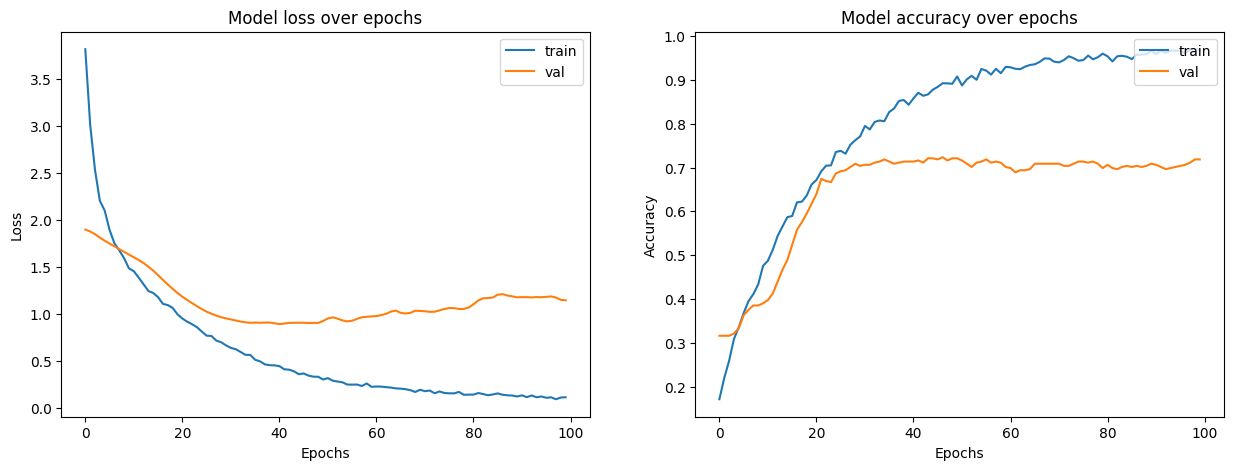

In [59]:
# Plot model performance during training
def plot_learning_curves(history):
    # Initialize the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot model loss during training
    ax1.plot(history.history["loss"])
    ax1.plot(history.history["val_loss"])
    ax1.legend(["train", "val"], loc="upper right")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.set_title("Model loss over epochs")

    # Plot model accuracy during training
    ax2.plot(history.history["acc"])
    ax2.plot(history.history["val_acc"])
    ax2.legend(["train", "val"], loc="upper right")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Model accuracy over epochs")
    plt.show()

plot_learning_curves(history_dnn)

In [60]:
# Generate new nodes. Each has a feature vector.
def generate_new_nodes(num_nodes):
    # Calculate probability of each feature (word attribute) in the feature vector.
    word_distribution = x_train.mean(axis=0)

    # Initialize new nodes vector
    new_nodes = []
    for _ in range(num_nodes):
        # Generate a random  for each feature
        rnd = np.random.uniform(size=len(word_distribution))

        # If the random value is less than the probability of the feature, the node has that feature / word attribute.
        # This makes sure that the frequency of the new nodes feature follows the same word attribute distribution of the original data.
        new_node = (rnd <= word_distribution).astype(int)

        # Append the new node feature vector of shape (1, 1433) to the new nodes vector
        new_nodes.append(new_node)

    # The new nodes array is of the shape (num_nodes, 1433)
    return np.array(new_nodes)

# Create new test nodes
test_nodes = generate_new_nodes(num_nodes = 3)

# Run the model with the new node to predict its subject
test_nodes_pred = dnn_model.predict(test_nodes)

# Output the subject class probability
for test_node_idx, probs in enumerate(test_nodes_pred):
    print("Test node: " + str(test_node_idx))
    print("- Word attribute features: " + str(np.nonzero(test_nodes[test_node_idx])))
    print("- Subjects: ")
    for class_idx, prob in enumerate(probs):
        print("   --- " + str(class_values[class_idx]) + ": " + str(prob))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
Test node: 0
- Word attribute features: (array([ 123,  215,  342,  558,  572,  642,  705,  745,  748,  880,  966,
        972, 1148, 1278, 1384, 1395]),)
- Subjects: 
   --- Case_Based: 0.102839395
   --- Genetic_Algorithms: 0.032536548
   --- Neural_Networks: 0.107365824
   --- Probabilistic_Methods: 0.37761873
   --- Reinforcement_Learning: 0.010831845
   --- Rule_Learning: 0.24030459
   --- Theory: 0.12850307
Test node: 1
- Word attribute features: (array([ 169,  242,  263,  264,  342,  367,  455,  513,  558,  637,  642,
        952,  995, 1008, 1048, 1058, 1109, 1242, 1294, 1336, 1369]),)
- Subjects: 
   --- Case_Based: 0.06044262
   --- Genetic_Algorithms: 0.083121225
   --- Neural_Networks: 0.20397401
   --- Probabilistic_Methods: 0.26920772
   --- Reinforcement_Learning: 0.0142619
   --- Rule_Learning: 0.076148264
   --- Theory: 0.29284433
Test node: 2
- Word attribute features: (array([  11,   47,  151,  264,  274,  290,  368,  433,  445, 

In [61]:
# Comments:
# Strong Confidence in Predictions: For nodes 0 and 1, the model shows very strong confidence in its predictions (over 99%), which suggests that the model has learned good representations for these categories and can classify them accurately.
# Less Confident in Certain Cases: Test Node 2, on the other hand, shows less confidence, with probabilities spread across a few categories. This could indicate that the features of this node are not strongly aligned with any single category.
# Feature Importance: It's interesting to note which word indices contribute to the predictions for each node. For instance, some features appear in multiple categories (e.g., indices 11, 17, and 47), and the model is able to use them to assign the correct subject with high confidence in most cases.
# Generalization: This test shows that the model is capable of handling new, unseen nodes that follow the same distribution as the training data, but the true test of generalization will be how well it performs on completely new and out-of-distribution data.

# GNN

In [62]:
# Graph information contains:
# - Node information.
# - Edge information.

# Node information: is an array of node features of shape [num_nodes, num_features].
node_features = tf.cast(papers.sort_values("paper_id")[list(feature_names)].to_numpy(), dtype=tf.dtypes.float32)

# Edge information: is an array of edges (sparse adjacency matrix) of shape [2, num_edges].
edges = citations[["source", "target"]].to_numpy().T

# Create graph info tuple with node information and edge information
graph_info = (node_features, edges)

print("Node features shape:", node_features.shape)
print("Edges shape:", edges.shape)

# Define a custom layer by extending the base class tensorflow.keras.layers.Layer
# Reference: https://keras.io/api/layers/base_layer/
class GNNLayer(layers.Layer):
    # Define a graph convolutional layer consisting of two operations:
    # - aggregate: sum of embeddings of neighbor nodes of a node.
    # - update: the node's embedding is updated by adding to aggregation result.

    # Defines custom layer attributes in __init__()
    def __init__(self, hidden_units_ffn, dropout_rate_ffn):
        # Inherit parent class initialization
        super().__init__()

        # Prepare the messages of neighbours, i.e., neighbour_messages
        self.ffn_prepare = create_ffn(hidden_units_ffn, dropout_rate_ffn)

        # Update the node embedding with the neighbour messages
        self.update_fn = create_ffn(hidden_units_ffn, dropout_rate_ffn)

    # Aggregate (sum) embeddings of neighbor nodes of a node
    # This aggregation can be sum, concat, mean, etc. In this sample code, we choose 'sum'.
    def aggregate(self, neighbour_messages, node_indices, node_embeddings):
        # Get number of nodes in the graph
        num_nodes = node_embeddings.shape[0]

        # Aggregate (sum) embeddings of neighbor nodes of all nodes; put results in a vector
        aggregated_message = tf.math.unsorted_segment_sum(neighbour_messages, node_indices, num_segments=num_nodes)

        # Return embedding result after aggregation
        return aggregated_message

    # Aggregation result from neighbors is added to the node's embedding to update the node
    def update(self, node_embeddings, aggregated_messages):
        # Add neighbors' embeddings to current node's embeddings, followed by a processing function (i.e., a feed forward network).
        node_embeddings = self.update_fn(node_embeddings + aggregated_messages)

        # Normalizes node embeddings to unit vectors, i.e., np.sum(node_embeddings[k]**2) = 1.0
        node_embeddings = tf.nn.l2_normalize(node_embeddings, axis=1)

        return node_embeddings

    # Function call() performs the logic of applying the layer to the input
    # Reference: https://keras.io/guides/making_new_layers_and_models_via_subclassing/
    def call(self, input_graph_info):
        # Process the input to produce the node_embeddings.
        # input (i.e., graph_info): a tuple of two elements: node_embeddings and edges
        # Returns: node_embeddings of shape [num_nodes, embedding_dim].

        # Extract node embeddings and edges from inputs, i.e., graph_info
        node_embeddings, edges = input_graph_info

        # Get source node indices and target neighbour indices from edges.
        source_node_indices, target_neighbour_indices = edges[0], edges[1]

        # Gather node embeddings of all target neighbours by their indices
        # neighbour_embeddings shape is [num_edges, embedding_dim]
        neighbour_embeddings = tf.gather(node_embeddings, target_neighbour_indices)

        # Prepare target neighbour embeddings by getting them through FFN (for complexity) to produce aggregation message
        neighbour_messages = self.ffn_prepare(neighbour_embeddings)

        # Aggregate the neighbour messages according to the current nodes, i.e., source_node_indices
        aggregated_messages = self.aggregate(neighbour_messages, source_node_indices, node_embeddings)

        # Update the current nodes with the aggregated messages.
        return self.update(node_embeddings, aggregated_messages)
    
# import layers
from tensorflow.keras import layers

# Define a custom model by extending the base class tensorflow.keras.Model
# Reference: https://keras.io/api/models/model/
class GNNModel(tf.keras.Model):
    # Implement model architecture in __init()__ function
    def __init__(self, node_features, edges, num_classes, hidden_units_ffn, dropout_rate_ffn):
        # Inherit parent class initialization
        super().__init__()

        # Unpack graph_info into node_features and edges
        self.node_features = node_features
        self.edges = edges
        self.num_classes = num_classes
        self.hidden_units_ffn = hidden_units_ffn
        self.dropout_rate_ffn = dropout_rate_ffn

        # Create a process layer.
        self.preprocess = create_ffn(self.hidden_units_ffn, self.dropout_rate_ffn)

        # Create the first GraphConv layer.
        self.conv1 = GNNLayer(self.hidden_units_ffn, self.dropout_rate_ffn)

        # Create the second GraphConv layer.
        self.conv2 = GNNLayer(self.hidden_units_ffn, self.dropout_rate_ffn)

        # Create a postprocess layer.
        self.postprocess = create_ffn(self.hidden_units_ffn, self.dropout_rate_ffn)

        # Create a classification layer.
        self.classify = layers.Dense(units=self.num_classes, activation=tf.nn.softmax,
                                      # Add kernel_regularizer for weight decay
                                      kernel_regularizer=tf.keras.regularizers.l2(0.01)) 

    # Implement the model's forward pass in call() function
    # input_node_indices is the list of nodes in x_train or x_test split
    def call(self, input_node_indices):
        # Ensure input_node_indices is a tensor
        if isinstance(input_node_indices, (list, tuple)):
            input_node_indices = tf.convert_to_tensor(input_node_indices, dtype=tf.int32)
        elif not isinstance(input_node_indices, tf.Tensor):
            raise ValueError("input_node_indices must be a list, tuple, or tf.Tensor")

        # Preprocess the node_features to produce node representations.
        x0 = self.preprocess(self.node_features)

        # Apply the first graph conv layer.
        x1 = self.conv1((x0, self.edges))

        # Skip connection.
        x2 = x1 + x0

        # Apply the second graph conv layer.
        x3 = self.conv2((x2, self.edges))

        # Skip connection.
        x4 = x3 + x2

        # Postprocess node embedding
        x5 = self.postprocess(x4)

        # Fetch node embeddings for the input_node_indices.
        node_embeddings = tf.gather(x5, input_node_indices)

        # Compute classification output of node embeddings of input_node_indices
        return self.classify(node_embeddings)

gnn_model = GNNModel(
    node_features=graph_info[0],  # contains node features
    edges=graph_info[1],  # contains edges
    num_classes=num_classes,
    hidden_units_ffn=hidden_units,
    dropout_rate_ffn=dropout_rate
)

# Instantiate and build the model on an arbitrary data sample: input_node_indices = [1], i.e. consisting of node index = 1
gnn_model(tf.constant([1]))

# Print model architecture
gnn_model.summary()

# Prepare input_node_indices of x_train, x_val and x_test.
# These variables contain list of node indices belonging to training, validation and test set.
x_train_gnn = train_data.paper_id.to_numpy()
x_val_gnn = val_data.paper_id.to_numpy()
x_test_gnn = test_data.paper_id.to_numpy()

# Compile the DNN model
gnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
)

# Implement early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=15,  # Increased patience to 15 epochs
    restore_best_weights=True  # Restore the best model weights
)

# Define learning rate scheduler
def lr_scheduler(epoch, lr):
    if epoch % 20 == 0 and epoch > 0:  # Reduce learning rate every 20 epochs
        return lr * 0.5
    else:
        return lr

# Implement learning rate scheduling
lr_schedule_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# Train and validate the DNN model with early stopping and learning rate scheduling
history_gnn = gnn_model.fit(
    x=x_train_gnn,
    y=y_train,
    epochs=100,
    batch_size=1024,
    validation_data=(x_val_gnn, y_val),
    callbacks=[early_stopping, lr_schedule_callback]  # Add both callbacks
)

gnn_model_eval = gnn_model.evaluate(x_test_gnn, y_test)
print("List of metrics" + str(gnn_model.metrics_names))  # List of possible metrics of the model evaluation, this is the metrics specified in the model.compile().
print("Test loss: " + str(gnn_model_eval[0]))
print("Test accuracy: " + str(gnn_model_eval[1]))

Node features shape: (2708, 1433)
Edges shape: (2, 5429)


Model: "gnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_10 (Sequential)      │ (2708, 32)             │        47,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gnn_layer (GNNLayer)            │ ?                      │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gnn_layer_1 (GNNLayer)          │ ?                      │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_15 (Sequential)      │ (2708, 32)             │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (1, 7)                 │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,271 (231.53 KB)

 Trainable params: 58,503 (228.53 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - acc: 0.1874 - loss: 2.0394 - val_acc: 0.3160 - val_loss: 1.9188 - learning_rate: 0.0100
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - acc: 0.3195 - loss: 1.8806 - val_acc: 0.4741 - val_loss: 1.7535 - learning_rate: 0.0100
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - acc: 0.4844 - loss: 1.6774 - val_acc: 0.5136 - val_loss: 1.5565 - learning_rate: 0.0100
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - acc: 0.5490 - loss: 1.4051 - val_acc: 0.5481 - val_loss: 1.3719 - learning_rate: 0.0100
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - acc: 0.6366 - loss: 1.1335 - val_acc: 0.5728 - val_loss: 1.2228 - learning_rate: 0.0100
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - acc: 0.6821 - loss: 0.9058 - val_acc: 0.5926 - val_loss: 1.1664 - learning_rate: 0.0100
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - acc: 0.7197 - loss: 0.7289 - val_acc: 0.7037 - val_loss: 1.1269 - learning_rate: 0.0100
Epoch 8/100
2/2

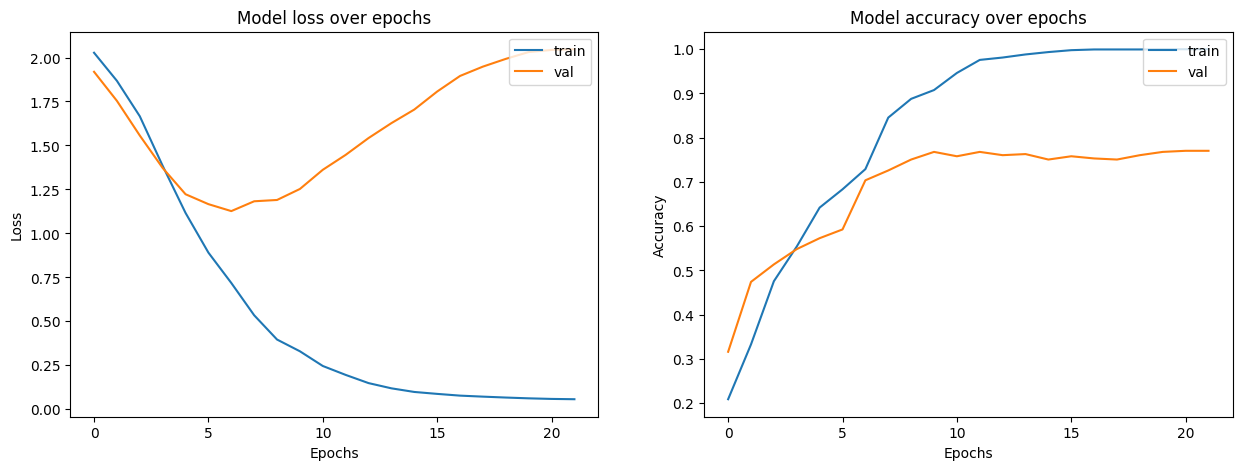

In [63]:
# plot the training gnn
plot_learning_curves(history_gnn)